# Proyek Klasifikasi Gambar: Animals10 Dataset
- **Nama:** Ahmad Latif Aulia Rahman
- **Email:** ahmadlatifar10@gmail.com
- **ID Dicoding:** zergavos

In [1]:
!pip install kagglehub

## Import Semua Packages/Library yang Digunakan

In [2]:
# import library standar untuk manipulasi file dan direktori
import os
import random
import shutil

# import library numerik dan visualisasi
import numpy as np
import matplotlib.pyplot as plt

# import tensorflow dan keras sebagai framework deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## Data Preparation

### Data Loading

In [3]:
# ===== DOWNLOAD DATASET =====
import kagglehub

path = kagglehub.dataset_download(
    "puneet6060/intel-image-classification"
)

print("Dataset path:", path)

# Dataset mentah
BASE_DIR = os.path.join(path, "seg_train", "seg_train")
print("Base dir:", BASE_DIR)

# ===== SUBSAMPLING DATASET =====
TARGET_PER_CLASS = 1800
WORK_DIR = "dataset_intel"

os.makedirs(WORK_DIR, exist_ok=True)

for cls in os.listdir(BASE_DIR):
    src = os.path.join(BASE_DIR, cls)
    dst = os.path.join(WORK_DIR, cls)
    os.makedirs(dst, exist_ok=True)

    images = os.listdir(src)
    random.shuffle(images)
    images = images[:TARGET_PER_CLASS]

    for img in images:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("Subsampling selesai")

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset path: /kaggle/input/intel-image-classification
Base dir: /kaggle/input/intel-image-classification/seg_train/seg_train
Subsampling selesai


### Data Preprocessing

#### Split Dataset

In [4]:
# Parameter dasar
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Direktori split dataset
SPLIT_DIR = "dataset_split"
TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# Rasio pembagian dataset
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

# Proses split dataset
for cls in os.listdir(WORK_DIR):
    cls_path = os.path.join(WORK_DIR, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(TRAIN_RATIO * total)
    val_end   = train_end + int(VAL_RATIO * total)

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for split_dir, split_imgs in zip(
        [TRAIN_DIR, VAL_DIR, TEST_DIR],
        [train_imgs, val_imgs, test_imgs]
    ):
        class_dir = os.path.join(split_dir, cls)
        os.makedirs(class_dir, exist_ok=True)

        for img in split_imgs:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(class_dir, img)
            )

print("Dataset berhasil dibagi menjadi train, validation, dan test")

# Dataset Training
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)


# Dataset Validation
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

# Dataset Testing
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

# Daftar nama kelas
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Total classes:", num_classes)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

Dataset berhasil dibagi menjadi train, validation, dan test
Found 8640 files belonging to 6 classes.
Found 1080 files belonging to 6 classes.
Found 1080 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total classes: 6


## Modelling

In [5]:
# import mobilenet
from tensorflow.keras.applications import MobileNetV2

# data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# base model
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# model training
model = keras.Sequential([

    # input
    layers.Input(shape=(224,224,3)),

    # augmentation (HANYA TRAINING)
    data_augmentation,

    # preprocessing tflite safe
    layers.Rescaling(1./127.5, offset=-1),

    # pretrained
    base_model,

    # conv2d wajib
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),

    # pooling wajib
    layers.MaxPooling2D((2,2)),

    # pooling global
    layers.GlobalAveragePooling2D(),

    # classifier
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    # output
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

# training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - accuracy: 0.6984 - loss: 0.8220 - val_accuracy: 0.9037 - val_loss: 0.2843
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.8646 - loss: 0.3863 - val_accuracy: 0.9019 - val_loss: 0.2926
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 714s 3s/step - accuracy: 0.8869 - loss: 0.3204 - val_accuracy: 0.9074 - val_loss: 0.2653
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 676s 3s/step - accuracy: 0.8868 - loss: 0.3054 - val_accuracy: 0.9037 - val_loss: 0.2817
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.8978 - loss: 0.2806 - val_accuracy: 0.9139 - val_loss: 0.2484
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 643s 2s/step - accuracy: 0.9052 - loss: 0.2599 - val_accuracy: 0.9111 - val_loss: 0.2540
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 711s 2s/step - accuracy: 0.9105 - loss: 0.2586 - val_accuracy: 0.9139 - val_loss: 0.2475
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 683s 3s/

## Evaluasi dan Visualisasi

34/34 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9019 - loss: 0.2690
test accuracy: 0.90


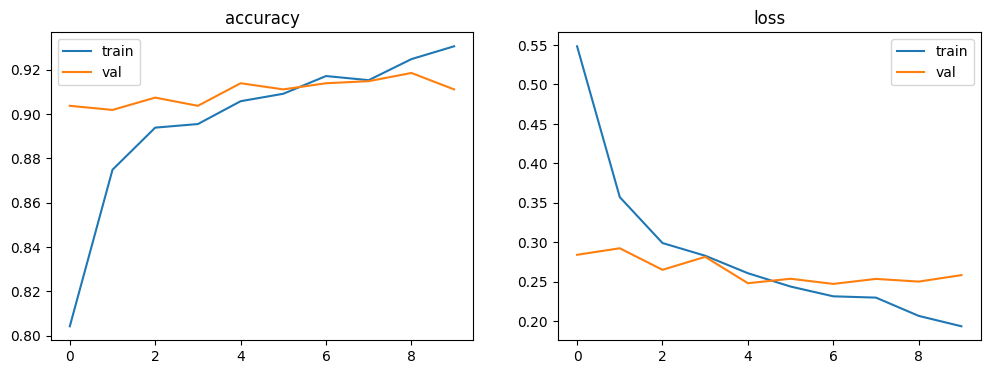

In [6]:
# evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"test accuracy: {test_acc:.2f}")

# plot accuracy dan loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("loss")

plt.show()

## Konversi Model

In [12]:
# build inference model (tanpa random layer)
inference_model = keras.Sequential([

    # input
    layers.Input(shape=(224,224,3)),

    # preprocessing saja
    layers.Rescaling(1./127.5, offset=-1),

    # pretrained backbone (reuse weights)
    base_model,

    # conv2d wajib
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),

    # pooling wajib
    layers.MaxPooling2D((2,2)),

    # pooling global
    layers.GlobalAveragePooling2D(),

    # classifier
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    # output
    layers.Dense(num_classes, activation="softmax")
])

# copy weights
inference_model.set_weights(model.get_weights())

inference_model.summary()

# savedmodel
os.makedirs("submission/saved_model", exist_ok=True)
inference_model.export("submission/saved_model")

# tflite
converter = tf.lite.TFLiteConverter.from_saved_model("submission/saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

os.makedirs("submission/tflite", exist_ok=True)
with open("submission/tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

with open("submission/tflite/label.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

print("tflite sukses tanpa error")

# tensorflowjs
!pip install -q tensorflowjs
!tensorflowjs_converter \
--input_format=tf_saved_model \
--output_format=tfjs_graph_model \
submission/saved_model \
submission/tfjs_model

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,767,238 (14.37 MB)

 Trainable params: 1,509,254 (5.76 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_186')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138059781582160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781585616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781585808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781583888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062650873168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781586000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781586384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781585040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781586192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138059781583504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1380

## Inference (Optional)

In [13]:
# inference satu gambar
from PIL import Image

img_path = os.path.join(
    TEST_DIR,
    class_names[0],
    os.listdir(os.path.join(TEST_DIR, class_names[0]))[0]
)

img = Image.open(img_path).resize(IMG_SIZE)
img_array = np.expand_dims(np.array(img), axis=0)

pred = model.predict(img_array)
print("predicted class:", class_names[np.argmax(pred)])

!pip freeze > requirements.txt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
predicted class: sea
